# Model Dengue Nowcasting (ARX + Joint Loss)

This notebook implements Model according to the requirements:
- Training set: months **<= split_month** (rolling splits)
- Test set: months **> split_month** (for evaluation only)
- Joint loss: WHO monthly supervision + OpenDengue yearly constraints + L2 regularization
- Use Data preprocessing estimates to impute missing WHO observations as $\tilde{x}$ for lagged inputs
- Output complete parameters, training curves, predictions, and plots

Overfitting control: L2 regularization + early stopping + train/test split.

In [1]:
# If needed, install dependencies in your environment:
# pip install -U pandas numpy torch matplotlib

# Prevent kernel crashes from OpenMP/MKL library conflicts
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

import json
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Tuple, List, Optional

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Further limit thread count
torch.set_num_threads(1)

In [2]:
@dataclass
class Step2Config:
    # Inputs
    data_path: str = 'master_data.csv'
    step1_predictions_path: str = os.path.join('outputs_step1_wiki', 'predictions_step1_monthly.csv')
    step1_pred_col: str = 'x_pred'

    # Modeling window
    start_month: str = '2021-01'

    # Rolling split evaluation (inclusive)
    rolling_start: str = '2024-11'
    rolling_end: str = '2025-12'
    test_horizon_months: int = 2  # only evaluate the next 2 months after each rolling split
    # To keep rolling evaluation runtime reasonable, you can override training budget per split
    rolling_max_epochs: int = 8000
    rolling_patience: int = 400

    # Target/source names in master_data.csv
    target_source: str = 'WHO'

    # Exogenous signals
    google_sources: Tuple[str, str] = (
        'Google_Trends_Dengue_fever',
        'Google_Trends_Dengue_vaccine',
    )


    # Wikipedia pageviews (external regressor)
    use_wiki: bool = True
    wiki_path: str = 'total_dengue_views.csv'
    wiki_month_col: str = 'Month'
    wiki_value_col: str = 'Total_Views'
    wiki_transform: str = 'log1p'  # 'log1p' or 'none'


    # Mosquito Wikipedia pageviews (external regressor as additional feature)
    use_mosquito: bool = True
    mosquito_path: str = 'monthly_mosquito_aggregate.csv'
    mosquito_month_col: str = 'timestamp'
    # If empty tuple, will use all numeric columns except the month column.
    mosquito_feature_cols: Tuple[str, ...] = ('TOTAL_MONTHLY_VIEWS',)
    mosquito_transform: str = 'log1p'  # 'log1p' or 'none'


    # Feature engineering
    lags_y: Tuple[int, ...] = (1, 2, 12)  # include seasonal lag 12 for monthly data
    use_month_dummies: bool = False  # set False to use Fourier terms instead

    # Seasonality (periodic time series)
    seasonal_period: int = 12  # monthly seasonality
    use_fourier: bool = True  # set True to use Fourier terms instead of month dummies
    fourier_K: int = 2         # number of Fourier harmonics
    # OpenDengue yearly proxy sources (priority)
    yearly_proxy_sources_priority: Tuple[str, ...] = (
        'OpenDengue_State_Aggregated',
        'OpenDengue_National_Yearly',
    )

    # Loss weights - Conservative: balance all three components
    lambda_who: float = 5.0  # Moderate WHO weight
    lambda_year: float = 0.3  # Strong yearly constraint to anchor predictions
    lambda_reg: float = 0.1  # Base regularization
    lambda_lag_reg: float = 5e-3  # Moderate lag regularization

    # Optimization
    epochs: int = 30000  
    lr: float = 3e-3  # Slower learning rate for stability
    seed: int = 42
    target_scale: float = 1000.0

    # Overfitting controls
    early_stop: bool = True
    patience: int = 1000  # Large patience for stable convergence
    min_delta: float = 1e-7  # Smaller threshold for early stopping

    # Scaling features (standardize using train stats)
    standardize_features: bool = True


    # Inference: approximate coefficient confidence intervals (normal approx via Hessian)
    compute_beta_ci: bool = True
    beta_ci_alpha: float = 0.05  # 95% CI by default
    # Output
    outdir: str = 'outputs_step2_mosquito'
    clip_nonnegative: bool = True


cfg = Step2Config()
cfg

Step2Config(data_path='master_data.csv', step1_predictions_path='outputs_step1_wiki/predictions_step1_monthly.csv', step1_pred_col='x_pred', start_month='2021-01', rolling_start='2024-11', rolling_end='2025-12', test_horizon_months=2, rolling_max_epochs=8000, rolling_patience=400, target_source='WHO', google_sources=('Google_Trends_Dengue_fever', 'Google_Trends_Dengue_vaccine'), use_wiki=True, wiki_path='total_dengue_views.csv', wiki_month_col='Month', wiki_value_col='Total_Views', wiki_transform='log1p', use_mosquito=True, mosquito_path='monthly_mosquito_aggregate.csv', mosquito_month_col='timestamp', mosquito_feature_cols=('TOTAL_MONTHLY_VIEWS',), mosquito_transform='log1p', lags_y=(1, 2, 12), use_month_dummies=False, seasonal_period=12, use_fourier=True, fourier_K=2, yearly_proxy_sources_priority=('OpenDengue_State_Aggregated', 'OpenDengue_National_Yearly'), lambda_who=5.0, lambda_year=0.3, lambda_reg=0.1, lambda_lag_reg=0.005, epochs=30000, lr=0.003, seed=42, target_scale=1000.0, e

In [3]:
def ensure_outdir(path: str) -> None:
    os.makedirs(path, exist_ok=True)


def parse_monthly_date_any(s: pd.Series) -> pd.Series:
    x = s.astype(str)
    is_ym = x.str.match('^[0-9]{4}-[0-9]{2}$')
    x = np.where(is_ym, x + '-01', x)
    dt = pd.to_datetime(x, errors='coerce')
    return dt


def load_master_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    expected = {'resolution', 'date', 'value', 'source'}
    missing = expected - set(df.columns)
    if missing:
        raise ValueError(f"master_data.csv missing columns: {sorted(missing)}")
    return df


def build_monthly_wide(df: pd.DataFrame) -> pd.DataFrame:
    m = df[df['resolution'].astype(str).str.lower().eq('monthly')].copy()
    m['date'] = parse_monthly_date_any(m['date'])
    m = m.dropna(subset=['date']).copy()
    wide = (
        m.pivot_table(index='date', columns='source', values='value', aggfunc='mean')
        .sort_index()
    )
    return wide


def build_yearly_proxy(df: pd.DataFrame, priority_sources: Tuple[str, ...]) -> pd.DataFrame:
    y = df[df['resolution'].astype(str).str.lower().eq('yearly')].copy()
    y['year'] = pd.to_numeric(y['date'], errors='coerce').astype('Int64')
    y = y.dropna(subset=['year'])
    y['year'] = y['year'].astype(int)

    pivot = (
        y.pivot_table(index='year', columns='source', values='value', aggfunc='mean')
        .sort_index()
    )

    chosen = []
    for year, row in pivot.iterrows():
        val = np.nan
        src = None
        for s in priority_sources:
            if s in row.index and pd.notna(row[s]):
                val = float(row[s])
                src = s
                break
        if pd.notna(val):
            chosen.append((year, val, src))

    return pd.DataFrame(chosen, columns=['year', 'od_total', 'od_source'])


def load_step1_predictions(cfg: Step2Config) -> pd.Series:
    if not os.path.exists(cfg.step1_predictions_path):
        return pd.Series(dtype=float)

    s1 = pd.read_csv(cfg.step1_predictions_path)
    if 'date' not in s1.columns:
        raise ValueError(f"Step 1 predictions file missing 'date': {cfg.step1_predictions_path}")

    s1['date'] = parse_monthly_date_any(s1['date'])
    s1 = s1.dropna(subset=['date']).copy()
    s1 = s1.sort_values('date')

    col = cfg.step1_pred_col if cfg.step1_pred_col in s1.columns else None
    if col is None:
        cand = [c for c in s1.columns if 'pred' in c.lower()]
        if not cand:
            cand = [c for c in s1.columns if c != 'date']
        if not cand:
            raise ValueError('No prediction column found in Step 1 predictions file.')
        col = cand[0]

    ser = s1.set_index('date')[col].astype(float)
    return ser



def load_wiki_monthly(cfg: Step2Config) -> pd.Series:
    """
    Load monthly Wikipedia pageviews time series.
    Expected columns: cfg.wiki_month_col (YYYY-MM) and cfg.wiki_value_col (numeric)
    Returns: pd.Series indexed by month (Timestamp at month start).
    """
    if (not getattr(cfg, 'use_wiki', False)) or (not os.path.exists(cfg.wiki_path)):
        return pd.Series(dtype=float)

    w = pd.read_csv(cfg.wiki_path)
    if cfg.wiki_month_col not in w.columns or cfg.wiki_value_col not in w.columns:
        raise ValueError(
            f"Wiki file must contain columns '{cfg.wiki_month_col}' and '{cfg.wiki_value_col}'. Got: {list(w.columns)}"
        )

    w = w.copy()
    w['date'] = parse_monthly_date_any(w[cfg.wiki_month_col])
    w = w.dropna(subset=['date']).sort_values('date')
    s = pd.to_numeric(w[cfg.wiki_value_col], errors='coerce')
    ser = pd.Series(s.values, index=w['date']).groupby(level=0).mean()
    return ser

def load_mosquito_monthly(cfg: Step2Config) -> pd.DataFrame:
    """
    Load monthly mosquito Wikipedia pageviews aggregate as a DataFrame.
    Expected: month column cfg.mosquito_month_col (YYYY-MM) and one or more numeric columns.
    Returns: DataFrame indexed by month (Timestamp at month start).
    """
    if (not getattr(cfg, 'use_mosquito', False)) or (not os.path.exists(cfg.mosquito_path)):
        return pd.DataFrame()

    m = pd.read_csv(cfg.mosquito_path)
    if cfg.mosquito_month_col not in m.columns:
        raise ValueError(
            f"Mosquito file must contain month column '{cfg.mosquito_month_col}'. Got: {list(m.columns)}"
        )

    m = m.copy()
    m['date'] = parse_monthly_date_any(m[cfg.mosquito_month_col])
    m = m.dropna(subset=['date']).sort_values('date')

    cols = list(getattr(cfg, 'mosquito_feature_cols', ()))
    if cols:
        missing = [c for c in cols if c not in m.columns]
        if missing:
            raise ValueError(f"Mosquito file missing columns: {missing}. Got: {list(m.columns)}")
        feat = m[cols].copy()
    else:
        feat_cols = [c for c in m.columns if c not in {cfg.mosquito_month_col, 'date'}]
        feat = m[feat_cols].copy()

    feat = feat.apply(pd.to_numeric, errors='coerce')
    feat['date'] = m['date'].values
    df_feat = feat.groupby('date').mean()
    return df_feat

def add_month_dummies(df: pd.DataFrame) -> pd.DataFrame:
    dt = pd.to_datetime(df.index)
    m = pd.get_dummies(dt.month, prefix='m', drop_first=True)
    m.index = df.index
    return pd.concat([df, m.astype(float)], axis=1)



def add_fourier_features(df: pd.DataFrame, period: int = 12, K: int = 2, prefix: str = 's') -> pd.DataFrame:
    """Add Fourier seasonality terms based on month-of-year."""
    dt = pd.to_datetime(df.index)
    m = dt.month.astype(float)
    out = df.copy()
    for k in range(1, int(K) + 1):
        out[f'{prefix}_sin{k}'] = np.sin(2 * np.pi * k * m / float(period))
        out[f'{prefix}_cos{k}'] = np.cos(2 * np.pi * k * m / float(period))
    return out



def build_design_matrix(wide: pd.DataFrame, cfg: Step2Config) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray, List[str]]:
    """
    Build design matrix.
    Critical fix: lagged variables x_tilde must be scaled by target_scale to match target scale.
    """
    start_dt = pd.to_datetime(cfg.start_month + '-01')
    wide = wide.loc[wide.index >= start_dt].copy()

    target = cfg.target_source
    if target not in wide.columns:
        wide[target] = np.nan

    g1, g2 = cfg.google_sources
    for g in [g1, g2]:
        if g not in wide.columns:
            raise ValueError(f"Missing Google source '{g}' in monthly data.")

    y_who = pd.to_numeric(wide[target], errors='coerce')

    step1_ser = load_step1_predictions(cfg)
    wide['STEP1_est'] = step1_ser.reindex(wide.index)

    # x_tilde: WHO when observed, else Step1 estimate (for lagged inputs)
    x_tilde = y_who.where(y_who.notna(), wide['STEP1_est'])
    
    # Critical fix: scale lagged variables to match target scale
    x_tilde_scaled = x_tilde / cfg.target_scale

    X_df = pd.DataFrame(index=wide.index)
    
    # Normalize Google Trends from [0, 100] to [0, 1]
    X_df['g_fever'] = pd.to_numeric(wide[g1], errors='coerce') / 100.0
    X_df['g_vaccine'] = pd.to_numeric(wide[g2], errors='coerce') / 100.0


    # Wikipedia pageviews regressor
    if getattr(cfg, 'use_wiki', False):
        wiki_ser = load_wiki_monthly(cfg)
        wide['WIKI_raw'] = wiki_ser.reindex(wide.index)
        wiki_raw = pd.to_numeric(wide['WIKI_raw'], errors='coerce')
        wiki_raw = wiki_raw.interpolate(limit_direction='both').ffill().bfill()
        if str(getattr(cfg, 'wiki_transform', 'log1p')).lower() == 'log1p':
            X_df['wiki_views'] = np.log1p(wiki_raw.astype(float))
        else:
            X_df['wiki_views'] = wiki_raw.astype(float)


    # Mosquito Wikipedia pageviews regressor (external feature)
    if getattr(cfg, 'use_mosquito', False):
        mosq_df = load_mosquito_monthly(cfg)
        if mosq_df is not None and len(mosq_df) > 0:
            mosq_df = mosq_df.reindex(wide.index)
            for c in mosq_df.columns:
                raw = pd.to_numeric(mosq_df[c], errors='coerce')
                raw = raw.interpolate(limit_direction='both').ffill().bfill()
                out_col = f"mosq_{str(c).lower()}"
                if str(getattr(cfg, 'mosquito_transform', 'log1p')).lower() == 'log1p':
                    X_df[out_col] = np.log1p(raw.astype(float))
                else:
                    X_df[out_col] = raw.astype(float)

    # Use scaled values for lagged variables
    for k in cfg.lags_y:
        X_df[f'x_tilde_lag{k}'] = x_tilde_scaled.shift(k)

    # Seasonality features (periodic time series)
    # Prefer Fourier terms when enabled; otherwise fall back to month dummies.
    if getattr(cfg, 'use_fourier', False):
        X_df = add_fourier_features(
            X_df,
            period=int(getattr(cfg, 'seasonal_period', 12)),
            K=int(getattr(cfg, 'fourier_K', 2)),
            prefix='s'
        )
    elif cfg.use_month_dummies:
        X_df = add_month_dummies(X_df)


    X_df['intercept'] = 1.0

    # Light imputation on exogenous features only (lags can remain NaN and be imputed later)
    
    exo_cols = ['g_fever', 'g_vaccine']
    if 'wiki_views' in X_df.columns:
        exo_cols.append('wiki_views')

    exo_cols += [c for c in X_df.columns if c.startswith('mosq_')]

    for col in exo_cols:
        if col in X_df.columns:
            X_df[col] = X_df[col].interpolate(limit_direction='both').ffill().bfill()

    feature_cols = [c for c in X_df.columns if c != 'intercept'] + ['intercept']
    X = X_df[feature_cols].to_numpy(dtype=np.float32)
    y = y_who.to_numpy(dtype=np.float32)
    mask_who = np.isfinite(y)


    return X_df, X, y, mask_who, feature_cols


def build_year_constraints(dates: pd.DatetimeIndex, yearly_proxy: pd.DataFrame, train_mask: np.ndarray) -> List[tuple]:
    df_dates = pd.DataFrame({'date': pd.to_datetime(dates)})
    df_dates['year'] = df_dates['date'].dt.year
    df_dates['month'] = df_dates['date'].dt.month

    constraints = []
    for _, r in yearly_proxy.iterrows():
        y = int(r['year'])
        od_total = float(r['od_total'])
        od_src = str(r['od_source'])

        idx = df_dates.index[df_dates['year'].eq(y)].to_numpy()
        if len(idx) == 0:
            continue

        # require all 12 months and all months in training window
        months_present = set(df_dates.loc[idx, 'month'].tolist())
        if months_present != set(range(1, 13)):
            continue
        if not np.all(train_mask[idx]):
            continue

        constraints.append((y, idx, od_total, od_src))

    return constraints


def time_series_split_mask(index: pd.DatetimeIndex, split_month: str, horizon_months: int = 2):
    split_dt = pd.to_datetime(split_month + '-01')
    test_end_dt = split_dt + pd.DateOffset(months=int(horizon_months))
    train_mask = index <= split_dt
    test_mask = (index > split_dt) & (index <= test_end_dt)
    return train_mask, test_mask


def standardize_features(X: np.ndarray, train_mask: np.ndarray, skip_cols: List[int] = None):
    """
    Standardize feature matrix.
    skip_cols: column indices to skip standardization (e.g., intercept term).
    """
    X2 = X.copy()
    n, p = X2.shape
    means = np.zeros(p, dtype=np.float32)
    stds = np.ones(p, dtype=np.float32)
    
    if skip_cols is None:
        skip_cols = []

    for j in range(p):
        col = X2[:, j]
        col_train = col[train_mask]
        
        # For intercept or specified columns, skip standardization
        if j in skip_cols:
            # Only impute NaN
            col = np.where(np.isfinite(col), col, 0.0)
            X2[:, j] = col
            continue
        
        m = np.nanmean(col_train)
        s = np.nanstd(col_train)
        if not np.isfinite(m):
            m = 0.0
        if (not np.isfinite(s)) or s <= 1e-12:
            s = 1.0
        means[j] = m
        stds[j] = s

        # impute NaNs with train mean, then standardize
        col = np.where(np.isfinite(col), col, m)
        X2[:, j] = (col - m) / s

    return X2, means, stds


def train_step2_joint_loss(
    X: np.ndarray,
    y_who: np.ndarray,
    mask_who: np.ndarray,
    year_constraints: List[tuple],
    train_mask: np.ndarray,
    cfg: Step2Config,
    feature_cols: List[str],
    ):
    """
    Train with differentiated regularization: stronger penalty on lag coefficients.
    """
    device = torch.device('cpu')

    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    y_scaled = y_who / cfg.target_scale
    y_t = torch.tensor(y_scaled, dtype=torch.float32, device=device)
    mask_who_t = torch.tensor(mask_who & train_mask, dtype=torch.bool, device=device)

    year_terms = []
    for (year, idx, od_total, od_src) in year_constraints:
        year_terms.append(
            (year, torch.tensor(idx, dtype=torch.long, device=device), float(od_total / cfg.target_scale), od_src)
        )

    # Identify lag feature indices for differentiated regularization
    lag_indices = [i for i, col in enumerate(feature_cols) if 'lag' in col.lower()]

    p = X_t.shape[1]
    beta = torch.nn.Parameter(torch.zeros(p, dtype=torch.float32, device=device))
    opt = torch.optim.Adam([beta], lr=cfg.lr)

    rows = []
    best_loss = np.inf
    best_beta = None
    bad_epochs = 0

    for epoch in range(1, cfg.epochs + 1):
        opt.zero_grad(set_to_none=True)
        x = X_t @ beta

        if mask_who_t.any():
            diff_who = x[mask_who_t] - y_t[mask_who_t]
            L_who = (diff_who ** 2).mean()
        else:
            L_who = torch.tensor(0.0, device=device)

        if len(year_terms) > 0:
            diffs = []
            for _, idx_t, od_total_scaled, _ in year_terms:
                year_sum = x.index_select(0, idx_t).sum()
                diffs.append((year_sum - od_total_scaled) ** 2)
            L_year = torch.stack(diffs).mean()
        else:
            L_year = torch.tensor(0.0, device=device)

        # Differentiated regularization: base + extra penalty on lag coefficients
        L_reg_base = (beta ** 2).sum()
        if lag_indices:
            beta_lag = beta[lag_indices]
            L_reg_lag = (beta_lag ** 2).sum()
        else:
            L_reg_lag = torch.tensor(0.0, device=device)
        
        L_reg = L_reg_base
        L_total = cfg.lambda_who * L_who + cfg.lambda_year * L_year + cfg.lambda_reg * L_reg + cfg.lambda_lag_reg * L_reg_lag
        L_total.backward()
        opt.step()

        val = float(L_total.detach().cpu().item())
        rows.append({
            'epoch': epoch,
            'L_total': val,
            'L_who': float(L_who.detach().cpu().item()),
            'L_year': float(L_year.detach().cpu().item()),
            'L_reg': float(L_reg.detach().cpu().item()),
            'L_lag_reg': float(L_reg_lag.detach().cpu().item()) if lag_indices else 0.0,
        })

        if not np.isfinite(val):
            raise RuntimeError('Training diverged (loss is NaN/Inf).')

        if cfg.early_stop:
            if val < best_loss - cfg.min_delta:
                best_loss = val
                best_beta = beta.detach().cpu().numpy().copy()
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= cfg.patience:
                    break

    beta_hat = beta.detach().cpu().numpy() if best_beta is None else best_beta
    loss_df = pd.DataFrame(rows)
    return beta_hat, loss_df

In [4]:

def compute_rmse(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.nanmean((y_true - y_pred) ** 2)))

def compute_mse(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.nanmean((y_true - y_pred) ** 2))


def safe_mape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < 1e-12, np.nan, np.abs(y_true))
    return float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0)


def make_predictions(X: np.ndarray, beta_hat: np.ndarray, cfg: Step2Config) -> np.ndarray:
    x_scaled = X @ beta_hat
    x = x_scaled * cfg.target_scale
    if cfg.clip_nonnegative:
        x = np.maximum(x, 0.0)
    return x


def plot_loss_curve(loss_df: pd.DataFrame, outdir: Path) -> None:
    fig = plt.figure()
    plt.plot(loss_df['epoch'], loss_df['L_total'], label='Total')
    if (loss_df['L_who'] != 0).any():
        plt.plot(loss_df['epoch'], loss_df['L_who'], label='WHO')
    if (loss_df['L_year'] != 0).any():
        plt.plot(loss_df['epoch'], loss_df['L_year'], label='Yearly')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (log scale)')
    plt.title('Training Loss Curve (Step 2)')
    plt.legend(loc=legend_loc)
    plt.tight_layout()
    fig.savefig(outdir / 'loss_curve_step2.png', dpi=200)
    plt.close(fig)



def plot_who_vs_pred(
    dates: pd.DatetimeIndex,
    y_who: np.ndarray,
    x_pred: np.ndarray,
    train_mask: np.ndarray,
    test_mask: np.ndarray,
    outdir: Path,
    fname: str = 'who_vs_pred_step2.png',
    title: str = None,
    x_step1: Optional[np.ndarray] = None,
    legend_loc: str = 'best',
) -> None:
    fig = plt.figure(figsize=(10, 4))

    display_mask = np.asarray(train_mask, dtype=bool) | np.asarray(test_mask, dtype=bool)
    x_pred_plot = np.asarray(x_pred, dtype=float).copy()
    x_pred_plot[~display_mask] = np.nan

    split_dt = dates[train_mask].max() if np.asarray(train_mask).any() else None
    test_end_dt = dates[test_mask].max() if np.asarray(test_mask).any() else None

    if split_dt is not None and test_end_dt is not None and test_end_dt >= split_dt:
        plt.axvspan(split_dt, test_end_dt, alpha=0.10, color='gray', zorder=0)

    plt.plot(dates, x_pred_plot, label='Predicted (Model)')
    plt.plot(dates, y_who, label='WHO observed')

    # Optional: overlay Step 1 predictions only for historical missing WHO months.
    # Future Step 1 extrapolation (purple line in the old plot) is intentionally removed.
    if x_step1 is not None:
        x_step1 = np.asarray(x_step1, dtype=float)
        y_who_arr = np.asarray(y_who, dtype=float)

        who_idx = np.where(np.isfinite(y_who_arr))[0]
        last_who = int(who_idx.max()) if who_idx.size > 0 else -1

        miss_mask = (~np.isfinite(y_who_arr)) & np.isfinite(x_step1)
        miss_idx = np.where(miss_mask)[0]

        if miss_idx.size > 0:
            runs = []
            s = miss_idx[0]
            prev = miss_idx[0]
            for k in miss_idx[1:]:
                if k == prev + 1:
                    prev = k
                else:
                    runs.append((s, prev))
                    s = prev = k
            runs.append((s, prev))

            first_hist = True

            for (a, b) in runs:
                # keep only historical missing blocks, not future extrapolation blocks
                if a > last_who:
                    continue

                seg_dates = list(dates[a:b + 1])
                seg_vals = list(x_step1[a:b + 1])

                if a - 1 >= 0 and np.isfinite(y_who_arr[a - 1]):
                    seg_dates = [dates[a - 1]] + seg_dates
                    seg_vals = [y_who_arr[a - 1]] + seg_vals

                if b + 1 < len(dates) and np.isfinite(y_who_arr[b + 1]):
                    seg_dates = seg_dates + [dates[b + 1]]
                    seg_vals = seg_vals + [y_who_arr[b + 1]]

                label = 'Data preprocessing (only where WHO is missing)' if first_hist else None
                first_hist = False
                plt.plot(seg_dates, seg_vals, color='#2ecc71', linewidth=2.5, label=label)

    if x_step1 is not None:
        y_who_arr = np.asarray(y_who, dtype=float)
        who_idx = np.where(np.isfinite(y_who_arr))[0]
        if who_idx.size > 0:
            first_who = who_idx.min()
            if first_who > 0 and (~np.isfinite(y_who_arr[:first_who])).any():
                plt.axvline(
                    dates[first_who],
                    linestyle=':',
                    color='black',
                    linewidth=2.0,
                    label='WHO begins'
                )

    if split_dt is not None:
        plt.axvline(split_dt, linestyle='--', color='gray', label='Train/Test split')
    if test_end_dt is not None:
        plt.axvline(test_end_dt, linestyle='--', color='lightgray', label='2-month test end')

    plt.xlabel('Date')
    plt.ylabel('Monthly dengue cases')
    plt.title(title if title is not None else 'WHO vs Prediction (Model)')
    plt.legend()
    plt.tight_layout()
    fig.savefig(outdir / fname, dpi=200)
    plt.close(fig)



def plot_yearly_vs_od(pred_df: pd.DataFrame, yearly_proxy: pd.DataFrame, outdir: Path) -> None:
    pred_year = pred_df.groupby('year', as_index=False)['x_pred'].sum().rename(columns={'x_pred': 'pred_year_total'})
    if yearly_proxy.empty:
        return
    merged = pred_year.merge(yearly_proxy, on='year', how='inner').sort_values('year')

    fig = plt.figure()
    plt.plot(merged['year'], merged['pred_year_total'], marker='o', label='Predicted yearly sum')
    plt.plot(merged['year'], merged['od_total'], marker='o', label='OpenDengue yearly total')
    plt.xlabel('Year')
    plt.ylabel('Total dengue cases (year)')
    plt.title('Yearly Aggregation: Prediction vs OpenDengue (Model)')
    plt.legend()
    plt.tight_layout()
    fig.savefig(outdir / 'yearly_vs_opendengue_step2.png', dpi=200)
    plt.close(fig)

    merged.to_csv(outdir / 'yearly_comparison_step2.csv', index=False)



def plot_step1_vs_step2(pred_df: pd.DataFrame, outdir: Path):
    if 'x_step1' not in pred_df.columns:
        return
    fig = plt.figure(figsize=(10, 4))
    dates = pd.to_datetime(pred_df['date'] + '-01')
    plt.plot(dates, pred_df['x_step1'], label='Data preprocessing')
    plt.plot(dates, pred_df['x_pred'], label='Model')
    plt.xlabel('Date')
    plt.ylabel('Monthly dengue cases')
    plt.title('Data preprocessing vs Model')
    plt.legend()
    plt.tight_layout()
    fig.savefig(outdir / 'step1_vs_step2.png', dpi=200)
    plt.close(fig)


from statistics import NormalDist

def compute_beta_ci_hessian(
    X: np.ndarray,
    y_who: np.ndarray,
    mask_who: np.ndarray,
    year_constraints: List[tuple],
    train_mask: np.ndarray,
    cfg: Step2Config,
    feature_cols: List[str],
    beta_hat: np.ndarray,
    feat_mean: Optional[np.ndarray] = None,
    feat_std: Optional[np.ndarray] = None,
    intercept_idx: Optional[int] = None,
    alpha: Optional[float] = None,
) -> dict:
    """
    Approximate coefficient confidence intervals under a Gaussian noise model
    on WHO-observed training months, using a normal approximation from the
    (quadratic) objective Hessian.

    Notes:
      - Treats yearly totals as deterministic constraints (no noise).
      - Returns CIs for:
          * beta (scaled target units)
          * coef_y_units_per_stdX (WHO units per 1 std of X, if standardized)
          * coef_y_units_per_rawX (WHO units per 1 raw-unit of X, if standardized)
    """
    if alpha is None:
        alpha = float(getattr(cfg, 'beta_ci_alpha', 0.05))

    beta_hat = np.asarray(beta_hat, dtype=float)
    p = beta_hat.shape[0]

    who_train_mask = (mask_who.astype(bool) & train_mask.astype(bool))
    idx = np.where(who_train_mask)[0]
    n_who = int(idx.size)
    if n_who == 0:
        nan = np.full(p, np.nan, dtype=float)
        return dict(
            beta_se=nan, beta_ci_lo=nan, beta_ci_hi=nan,
            coef_std_se=nan, coef_std_ci_lo=nan, coef_std_ci_hi=nan,
            coef_raw_se=nan, coef_raw_ci_lo=nan, coef_raw_ci_hi=nan,
            sigma2=np.nan, df_eff=np.nan,
        )

    Xw = np.asarray(X[idx, :], dtype=float)
    y_scaled = np.asarray(y_who[idx], dtype=float) / float(cfg.target_scale)

    # Build Hessian (scaled units, matches train_step2_joint_loss)
    lam_who = float(cfg.lambda_who)
    lam_year = float(cfg.lambda_year)
    lam_reg = float(cfg.lambda_reg)
    lam_lag = float(cfg.lambda_lag_reg)

    # WHO term: (lam_who / n_who) * ||Xw beta - y||^2
    H_core = (lam_who / n_who) * (Xw.T @ Xw)

    # Year constraints term: (lam_year / n_year) * sum_y (c_y^T beta - od_y)^2
    n_year = int(len(year_constraints))
    if n_year > 0 and lam_year != 0.0:
        for (_, idx_year, od_total, _) in year_constraints:
            c = np.asarray(X[np.asarray(idx_year, dtype=int), :], dtype=float).sum(axis=0)
            H_core += (lam_year / n_year) * np.outer(c, c)

    # Regularization terms
    H_core += lam_reg * np.eye(p, dtype=float)

    lag_indices = [i for i, col in enumerate(feature_cols) if 'lag' in str(col).lower()]
    if lag_indices and lam_lag != 0.0:
        D = np.zeros(p, dtype=float)
        D[np.asarray(lag_indices, dtype=int)] = 1.0
        H_core += lam_lag * np.diag(D)

    # Full Hessian of L_total
    Hess = 2.0 * H_core

    # Invert Hessian (small p; ridge-like => should be well-conditioned)
    try:
        Hess_inv = np.linalg.inv(Hess)
    except np.linalg.LinAlgError:
        Hess_inv = np.linalg.pinv(Hess)

    # Effective degrees of freedom for WHO fitted values (approx.)
    XtX = Xw.T @ Xw
    df_eff = (2.0 * lam_who / n_who) * float(np.trace(XtX @ Hess_inv))

    # Residual variance estimate on WHO-observed training months (scaled)
    r = (Xw @ beta_hat) - y_scaled
    RSS = float(np.sum(r ** 2))
    denom = max(n_who - df_eff, 1.0)
    sigma2 = RSS / denom

    # Var(beta_hat) = sigma2 * A A^T, A = Hess_inv * (2 lam_who / n_who) * Xw^T
    cfac = (2.0 * lam_who / n_who)
    Var_beta = sigma2 * (cfac ** 2) * (Hess_inv @ XtX @ Hess_inv)

    se_beta = np.sqrt(np.clip(np.diag(Var_beta), 0.0, np.inf))

    z = float(NormalDist().inv_cdf(1.0 - alpha / 2.0))
    ci_lo = beta_hat - z * se_beta
    ci_hi = beta_hat + z * se_beta

    # Convert to WHO units per standardized X
    coef_std = beta_hat * float(cfg.target_scale)
    coef_std_se = se_beta * float(cfg.target_scale)
    coef_std_ci_lo = ci_lo * float(cfg.target_scale)
    coef_std_ci_hi = ci_hi * float(cfg.target_scale)

    # Convert to WHO units per raw X (requires feat_std/feat_mean if standardized)
    if (feat_std is not None) and (feat_mean is not None):
        feat_std = np.asarray(feat_std, dtype=float)
        feat_mean = np.asarray(feat_mean, dtype=float)

        # Transform covariance into coef_std space
        Var_coef_std = (float(cfg.target_scale) ** 2) * Var_beta

        # Build linear transform T: coef_std -> coef_raw (including intercept adjustment)
        T = np.zeros((p, p), dtype=float)
        for j in range(p):
            T[j, j] = 1.0 / float(feat_std[j]) if float(feat_std[j]) != 0.0 else 0.0

        if intercept_idx is not None:
            # intercept_raw = coef_std[int] - sum_j mean_j * (coef_std[j]/std_j)
            T[intercept_idx, :] = 0.0
            T[intercept_idx, intercept_idx] = 1.0
            for j in range(p):
                if j == intercept_idx:
                    continue
                stdj = float(feat_std[j]) if float(feat_std[j]) != 0.0 else 1.0
                T[intercept_idx, j] = - float(feat_mean[j]) / stdj

        Var_coef_raw = T @ Var_coef_std @ T.T
        se_raw = np.sqrt(np.clip(np.diag(Var_coef_raw), 0.0, np.inf))
        coef_raw = (coef_std / feat_std)
        if intercept_idx is not None:
            coef_raw = coef_raw.copy()
            coef_raw[intercept_idx] = coef_std[intercept_idx] - float(np.dot(coef_raw, feat_mean))

        coef_raw_ci_lo = coef_raw - z * se_raw
        coef_raw_ci_hi = coef_raw + z * se_raw
    else:
        se_raw = np.full(p, np.nan, dtype=float)
        coef_raw = np.full(p, np.nan, dtype=float)
        coef_raw_ci_lo = np.full(p, np.nan, dtype=float)
        coef_raw_ci_hi = np.full(p, np.nan, dtype=float)

    return dict(
        beta_se=se_beta,
        beta_ci_lo=ci_lo,
        beta_ci_hi=ci_hi,
        coef_std_se=coef_std_se,
        coef_std_ci_lo=coef_std_ci_lo,
        coef_std_ci_hi=coef_std_ci_hi,
        coef_raw_se=se_raw,
        coef_raw_ci_lo=coef_raw_ci_lo,
        coef_raw_ci_hi=coef_raw_ci_hi,
        Var_beta=Var_beta,
        z=z,
        sigma2=sigma2,
        df_eff=df_eff,
    )


## 1) Load Data, Build Features, and Split Train/Test

- Use Data preprocessing predictions to impute missing WHO observations for $\tilde{x}$
- Build ARX features: Google Trends + lagged variables + month dummies
- Training/Test split is evaluated over a rolling set of split months.

In [5]:
import copy
from pathlib import Path

df = load_master_csv(cfg.data_path)
wide = build_monthly_wide(df)
yearly_proxy = build_yearly_proxy(df, cfg.yearly_proxy_sources_priority)

X_df, X_raw, y_who, mask_who, feature_cols = build_design_matrix(wide, cfg)

# Step 1 predictions aligned to the full monthly index (used only for plotting overlays)
step1_full = load_step1_predictions(cfg).reindex(X_df.index).to_numpy(dtype=float)

rolling_split_months = pd.period_range(cfg.rolling_start, cfg.rolling_end, freq='M').strftime('%Y-%m').tolist()

print('Total months:', len(X_df))
print('WHO observed months:', int(mask_who.sum()))
print('Feature count:', X_raw.shape[1])
print('Rolling split months:', rolling_split_months)
print('Test horizon (months):', cfg.test_horizon_months)


Total months: 62
WHO observed months: 25
Feature count: 12
Rolling split months: ['2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12']
Test horizon (months): 2


## 2) Train Model (Joint Loss + Yearly Constraints + Early Stopping)

- Only training period participates in optimization
- WHO monthly + yearly proxy + L2 regularization
- Early stopping to prevent overfitting

In [6]:

# Rolling train/test split evaluation: each split trains up to split_month
# and tests only on the next cfg.test_horizon_months months.
outdir = Path(cfg.outdir)
roll_dir = outdir / 'rolling_splits'
ensure_outdir(str(roll_dir))

metric_rows = []
coef_rows = []
pred_rows = []

# Find intercept column index (should not be standardized)
intercept_idx = feature_cols.index('intercept') if 'intercept' in feature_cols else None
skip_cols = [intercept_idx] if intercept_idx is not None else []

for split_month in rolling_split_months:
    train_mask, test_mask = time_series_split_mask(
        X_df.index,
        split_month,
        horizon_months=int(cfg.test_horizon_months),
    )

    if int(train_mask.sum()) == 0 or int(test_mask.sum()) == 0:
        continue

    # Standardize features (using training set statistics only, skip intercept)
    if cfg.standardize_features:
        X_proc, feat_mean, feat_std = standardize_features(X_raw, train_mask, skip_cols=skip_cols)
    else:
        X_proc = X_raw.copy()
        feat_mean = None
        feat_std = None

    # Year constraints (only full years entirely in training window)
    year_constraints = build_year_constraints(X_df.index, yearly_proxy, train_mask)
    year_years = [int(t[0]) for t in year_constraints]

    # Copy cfg for this split (optionally override training budget for rolling)
    cfg_i = copy.deepcopy(cfg)
    cfg_i.split_month = split_month
    cfg_i.epochs = int(getattr(cfg, 'rolling_max_epochs', cfg.epochs))
    cfg_i.patience = int(getattr(cfg, 'rolling_patience', cfg.patience))

    beta_hat, loss_df = train_step2_joint_loss(
        X=X_proc,
        y_who=y_who,
        mask_who=mask_who,
        year_constraints=year_constraints,
        train_mask=train_mask,
        cfg=cfg_i,
        feature_cols=feature_cols,
    )

    # -------------------------
    # Coefficients per split
    # -------------------------
    beta_hat = np.asarray(beta_hat, dtype=float)

    # Convert to WHO units (because make_predictions multiplies by target_scale)
    coef_y_units_per_stdX = beta_hat * float(cfg_i.target_scale)

    # Convert coefficients back to *raw* feature scale so they are comparable across splits
    # If X_j was standardized as (raw - mean)/std, then:
    #   y = sum_j (coef/std_j) * raw_j  +  (intercept - sum_j (coef/std_j)*mean_j)
    if cfg.standardize_features and (feat_mean is not None) and (feat_std is not None):
        coef_y_units_per_rawX = coef_y_units_per_stdX / feat_std
        if intercept_idx is not None:
            intercept_raw = coef_y_units_per_stdX[intercept_idx] - float(np.dot(coef_y_units_per_rawX, feat_mean))
            coef_y_units_per_rawX = coef_y_units_per_rawX.copy()
            coef_y_units_per_rawX[intercept_idx] = intercept_raw
    else:
        coef_y_units_per_rawX = coef_y_units_per_stdX.copy()

    # -------------------------
    # Approx. coefficient CIs (normal approx via Hessian)
    # -------------------------
    ci = None
    if getattr(cfg_i, 'compute_beta_ci', True):
        ci = compute_beta_ci_hessian(
            X=X_proc,
            y_who=y_who,
            mask_who=mask_who,
            year_constraints=year_constraints,
            train_mask=train_mask,
            cfg=cfg_i,
            feature_cols=feature_cols,
            beta_hat=beta_hat,
            feat_mean=feat_mean,
            feat_std=feat_std,
            intercept_idx=intercept_idx,
            alpha=float(getattr(cfg_i, 'beta_ci_alpha', 0.05)),
        )

    for j, name in enumerate(feature_cols):
        coef_rows.append({
            'split_month': split_month,
            'feature': name,
            'beta_hat': float(beta_hat[j]),
            'coef_y_units_per_stdX': float(coef_y_units_per_stdX[j]),
            'coef_y_units_per_rawX': float(coef_y_units_per_rawX[j]),
            'beta_se': float(ci['beta_se'][j]) if ci is not None else np.nan,
            'beta_ci_lo': float(ci['beta_ci_lo'][j]) if ci is not None else np.nan,
            'beta_ci_hi': float(ci['beta_ci_hi'][j]) if ci is not None else np.nan,
            'coef_std_se': float(ci['coef_std_se'][j]) if ci is not None else np.nan,
            'coef_std_ci_lo': float(ci['coef_std_ci_lo'][j]) if ci is not None else np.nan,
            'coef_std_ci_hi': float(ci['coef_std_ci_hi'][j]) if ci is not None else np.nan,
            'coef_raw_se': float(ci['coef_raw_se'][j]) if ci is not None else np.nan,
            'coef_raw_ci_lo': float(ci['coef_raw_ci_lo'][j]) if ci is not None else np.nan,
            'coef_raw_ci_hi': float(ci['coef_raw_ci_hi'][j]) if ci is not None else np.nan,
        })

    # Predict for all months
    x_pred = make_predictions(X_proc, beta_hat, cfg_i)

    # Evaluation (only on months with WHO observations)
    mask_train_who = train_mask & mask_who
    mask_test_who = test_mask & mask_who

    rmse_train = compute_rmse(y_who[mask_train_who], x_pred[mask_train_who]) if mask_train_who.any() else np.nan
    mape_train = safe_mape(y_who[mask_train_who], x_pred[mask_train_who]) if mask_train_who.any() else np.nan
    rmse_test = compute_rmse(y_who[mask_test_who], x_pred[mask_test_who]) if mask_test_who.any() else np.nan
    mape_test = safe_mape(y_who[mask_test_who], x_pred[mask_test_who]) if mask_test_who.any() else np.nan

    mse_train = compute_mse(y_who[mask_train_who], x_pred[mask_train_who]) if mask_train_who.any() else np.nan
    mse_test = compute_mse(y_who[mask_test_who], x_pred[mask_test_who]) if mask_test_who.any() else np.nan

    # Seasonal naive baseline using last year's same month (if lag{seasonal_period} feature exists)
    rmse_test_seasonal_naive = np.nan
    mape_test_seasonal_naive = np.nan
    mse_test_seasonal_naive = np.nan
    seasonal_naive = np.full(len(X_df.index), np.nan, dtype=float)
    seasonal_lag_name = f'x_tilde_lag{int(getattr(cfg_i, "seasonal_period", 12))}'
    if seasonal_lag_name in feature_cols:
        j_lag = feature_cols.index(seasonal_lag_name)
        seasonal_naive = X_raw[:, j_lag] * float(cfg_i.target_scale)  # back to WHO units
        rmse_test_seasonal_naive = compute_rmse(y_who[mask_test_who], seasonal_naive[mask_test_who]) if mask_test_who.any() else np.nan
        mape_test_seasonal_naive = safe_mape(y_who[mask_test_who], seasonal_naive[mask_test_who]) if mask_test_who.any() else np.nan
        mse_test_seasonal_naive = compute_mse(y_who[mask_test_who], seasonal_naive[mask_test_who]) if mask_test_who.any() else np.nan

    metric_rows.append({
        'split_month': split_month,
        'test_end_month': pd.to_datetime(X_df.index[test_mask].max()).strftime('%Y-%m'),
        'test_horizon_months': int(cfg.test_horizon_months),
        'n_train_months': int(train_mask.sum()),
        'n_test_months': int(test_mask.sum()),
        'n_train_who': int(mask_train_who.sum()),
        'n_test_who': int(mask_test_who.sum()),
        'n_year_constraints': int(len(year_constraints)),
        'year_constraint_years': ';'.join(map(str, year_years)) if len(year_years) else '',
        'RMSE_train': rmse_train,
        'MSE_train': mse_train,
        'MAPE_train_%': mape_train,
        'RMSE_test': rmse_test,
        'MSE_test': mse_test,
        'MAPE_test_%': mape_test,
        'RMSE_test_seasonal_naive': rmse_test_seasonal_naive,
        'MSE_test_seasonal_naive': mse_test_seasonal_naive,
        'MAPE_test_seasonal_naive_%': mape_test_seasonal_naive,
        'epochs_used': int(loss_df['epoch'].max()) if (not loss_df.empty and 'epoch' in loss_df.columns) else np.nan,
    })

    # Detailed rows for horizon-specific plots (1-month-ahead vs 2-month-ahead)
    test_idx = np.where(np.asarray(test_mask, dtype=bool))[0]
    split_dt = pd.Timestamp(split_month + '-01')
    for h, idx_i in enumerate(test_idx, start=1):
        target_dt = pd.Timestamp(X_df.index[idx_i])
        y_true_i = float(y_who[idx_i]) if np.isfinite(y_who[idx_i]) else np.nan
        pred_i = float(x_pred[idx_i]) if np.isfinite(x_pred[idx_i]) else np.nan
        bench_i = float(seasonal_naive[idx_i]) if np.isfinite(seasonal_naive[idx_i]) else np.nan
        pred_rows.append({
            'split_month': split_month,
            'split_date': split_dt,
            'target_month': target_dt.strftime('%Y-%m'),
            'target_date': target_dt,
            'horizon_step': int(h),
            'x_pred': pred_i,
            'benchmark_t12': bench_i,
            'y_who': y_true_i,
            'model_squared_error': float((pred_i - y_true_i) ** 2) if np.isfinite(pred_i) and np.isfinite(y_true_i) else np.nan,
            'benchmark_squared_error': float((bench_i - y_true_i) ** 2) if np.isfinite(bench_i) and np.isfinite(y_true_i) else np.nan,
        })

    # Plot: prediction vs WHO (train period + next 2-month forecast window only)
    fname = f'who_vs_pred_step2_split_{split_month}.png'
    title = f'WHO vs Predicted (Model) — split_month={split_month}, horizon={int(cfg.test_horizon_months)} months'
    plot_who_vs_pred(
        X_df.index,
        y_who,
        x_pred,
        train_mask,
        test_mask,
        roll_dir,
        fname=fname,
        title=title,
        x_step1=step1_full,
        legend_loc='upper left' if split_month == '2025-12' else 'best',
    )

# -------------------------
# Save metrics + coefficients
# -------------------------
rolling_metrics_df = pd.DataFrame(metric_rows).sort_values('split_month')
coef_long_df = pd.DataFrame(coef_rows)
rolling_pred_df = pd.DataFrame(pred_rows).sort_values(['horizon_step', 'target_date', 'split_date'])

rolling_metrics_df.to_csv(roll_dir / 'rolling_split_metrics.csv', index=False)
coef_long_df.to_csv(roll_dir / 'rolling_split_coefficients_long.csv', index=False)
coef_long_df.to_csv(roll_dir / 'rolling_split_coefficients_with_ci_long.csv', index=False)
rolling_pred_df.to_csv(roll_dir / 'rolling_predictions_long.csv', index=False)

# Wide-format coefficient tables (easier to scan in Excel)
coef_raw_wide = coef_long_df.pivot(index='split_month', columns='feature', values='coef_y_units_per_rawX').reset_index()
coef_std_wide = coef_long_df.pivot(index='split_month', columns='feature', values='coef_y_units_per_stdX').reset_index()
coef_raw_wide.to_csv(roll_dir / 'rolling_split_coefficients_raw_wide.csv', index=False)
coef_std_wide.to_csv(roll_dir / 'rolling_split_coefficients_std_wide.csv', index=False)

print('Saved rolling plots to:', roll_dir.resolve())
print('Saved metrics to:', (roll_dir / 'rolling_split_metrics.csv').resolve())
print('Saved coefficients (long) to:', (roll_dir / 'rolling_split_coefficients_long.csv').resolve())
print('Saved coefficients w/ CI (long) to:', (roll_dir / 'rolling_split_coefficients_with_ci_long.csv').resolve())
print('Saved horizon-specific predictions to:', (roll_dir / 'rolling_predictions_long.csv').resolve())
print('Saved coefficients (wide/raw) to:', (roll_dir / 'rolling_split_coefficients_raw_wide.csv').resolve())
print('Saved coefficients (wide/std) to:', (roll_dir / 'rolling_split_coefficients_std_wide.csv').resolve())

rolling_metrics_df

# Coefficient CIs for the last rolling split (raw units)
_last = rolling_metrics_df['split_month'].iloc[-1]
coef_ci_last = (coef_long_df[coef_long_df['split_month'].eq(_last)]
                .loc[:, ['feature','coef_y_units_per_rawX','coef_raw_ci_lo','coef_raw_ci_hi']]
                .sort_values('feature'))
coef_ci_last


Saved rolling plots to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits
Saved metrics to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/rolling_split_metrics.csv
Saved coefficients (long) to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/rolling_split_coefficients_long.csv
Saved coefficients w/ CI (long) to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/rolling_split_coefficients_with_ci_long.csv
Saved horizon-specific predictions to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/rolling_predictions_long.csv
Saved coefficients (wide/raw) to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/rolling_split_coefficients_raw_wide.csv
Saved coefficients (wide/std) to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosq

,feature,coef_y_units_per_rawX,coef_raw_ci_lo,coef_raw_ci_hi
156,g_fever,49515.729664,31690.271084,67341.188245
157,g_vaccine,758.867050,-8697.628700,10215.362800
167,intercept,-18596.247753,-28905.741250,-8286.754256
159,mosq_total_monthly_views,4249.214721,1510.825803,6987.603638
164,s_cos1,-463.338479,-3439.452166,2512.775208
166,s_cos2,-953.135485,-3270.996274,1364.725303
163,s_sin1,-5456.755942,-9091.573955,-1821.937929
165,s_sin2,-2656.467691,-4732.078811,-580.856572
158,wiki_views,-2167.838062,-3754.239850,-581.436274
160,x_tilde_lag1,113.681478,-86.981177,314.344133


In [7]:
# Save rolling metrics table
if 'rolling_metrics_df' in globals() and len(rolling_metrics_df) > 0:
    rolling_metrics_df.to_csv(roll_dir / 'rolling_split_metrics.csv', index=False)
    print('Saved rolling plots to:', roll_dir.resolve())
    print('Saved metrics to:', (roll_dir / 'rolling_split_metrics.csv').resolve())
else:
    print('No rolling metrics produced. Check rolling_split_months and data coverage.')


Saved rolling plots to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits
Saved metrics to: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/rolling_split_metrics.csv


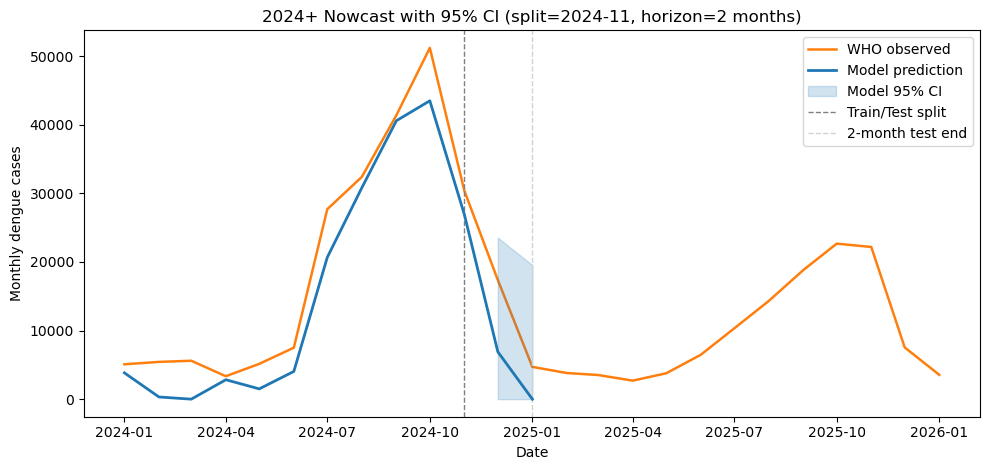

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2024-11.png


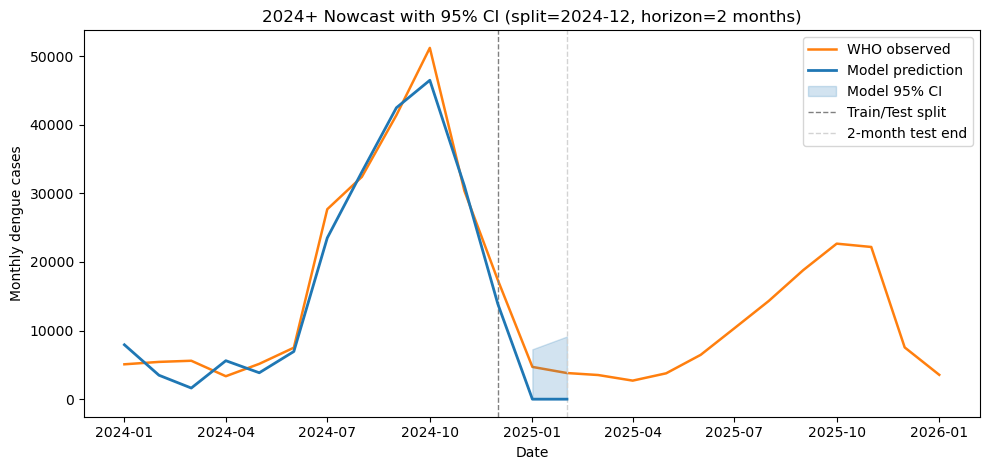

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2024-12.png


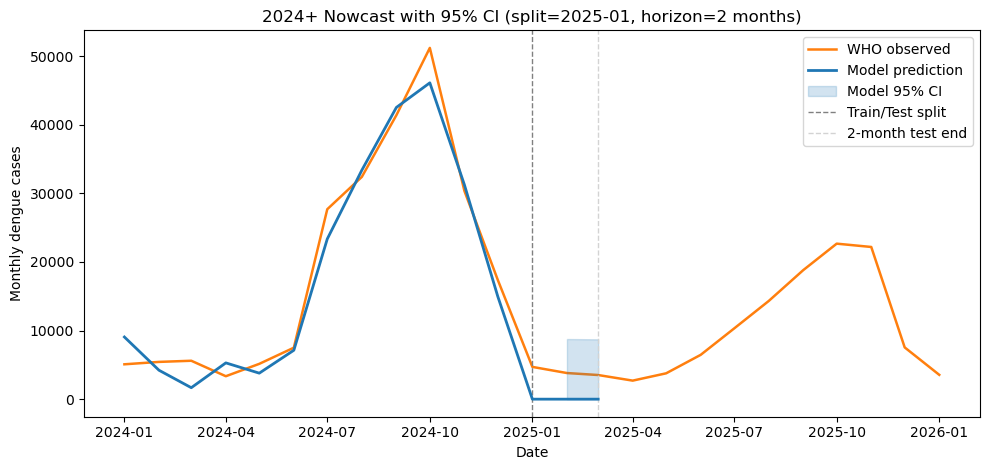

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2025-01.png


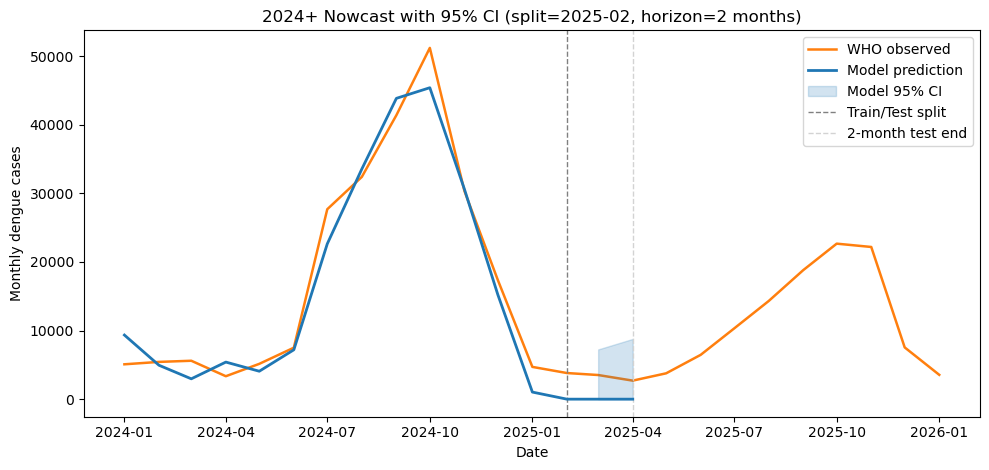

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2025-02.png


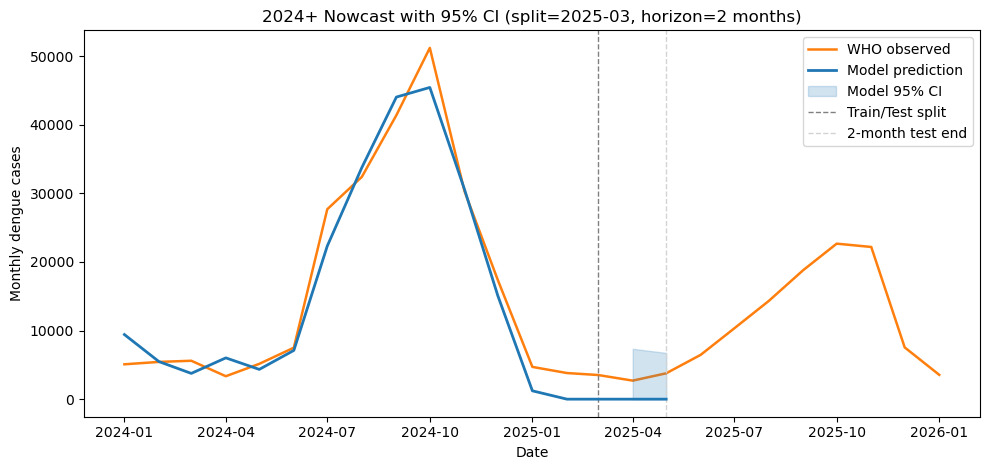

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2025-03.png


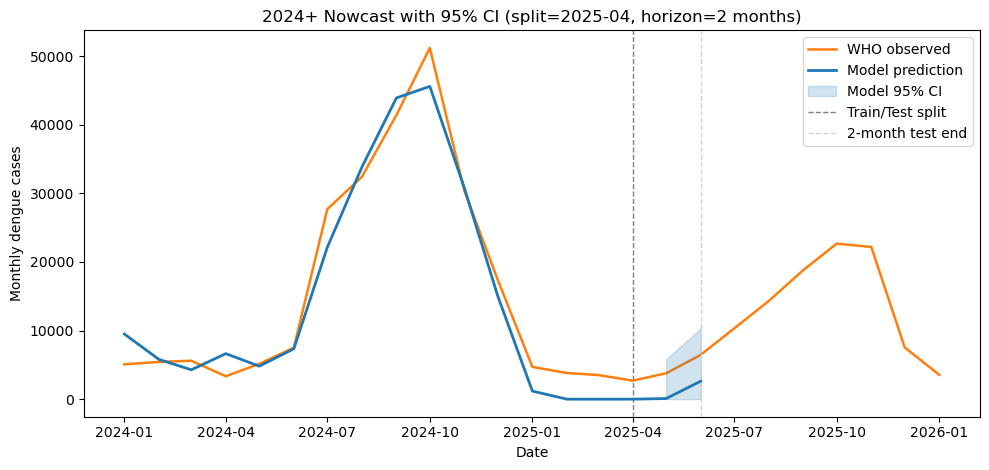

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2025-04.png


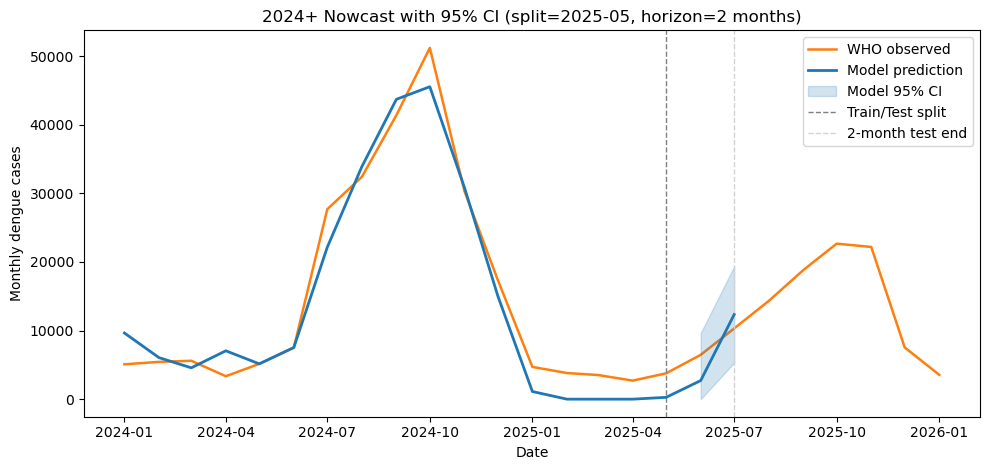

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2025-05.png


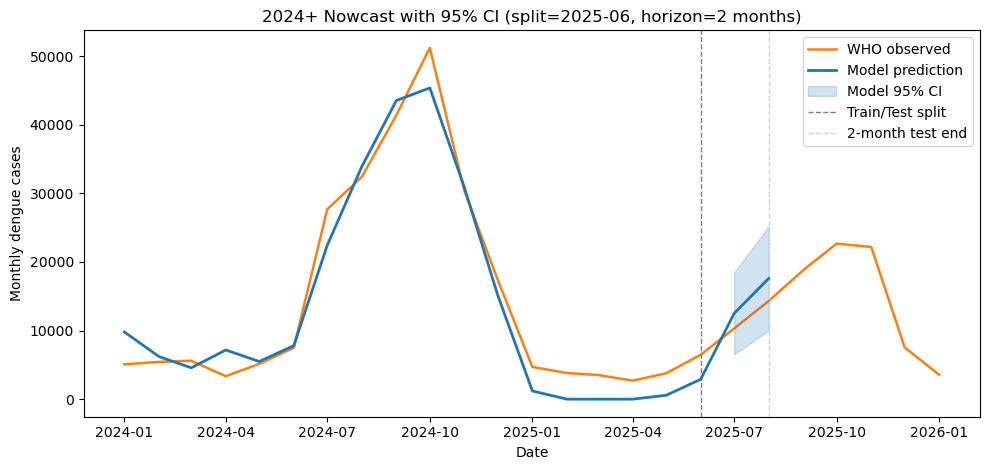

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2025-06.png


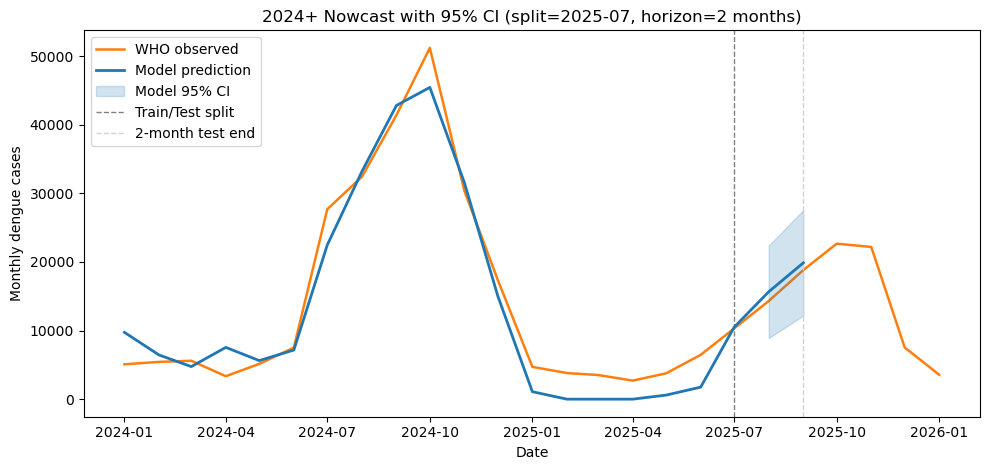

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2025-07.png


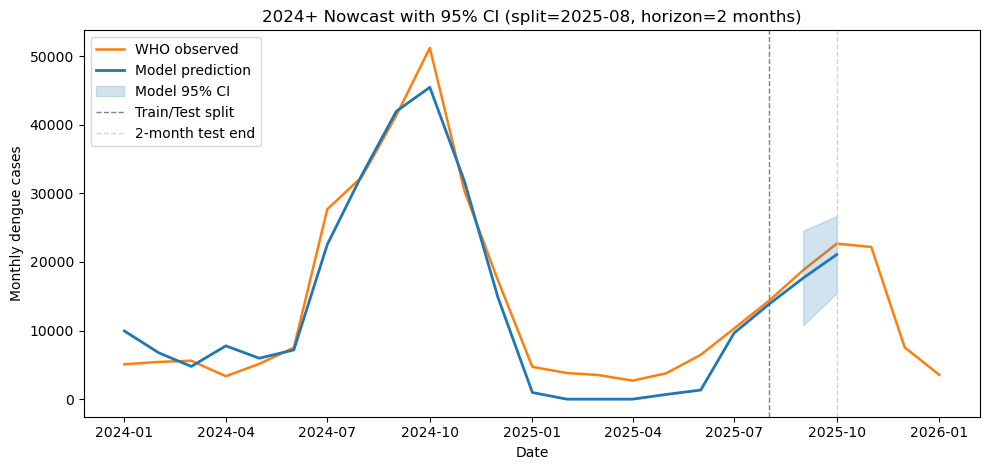

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2025-08.png


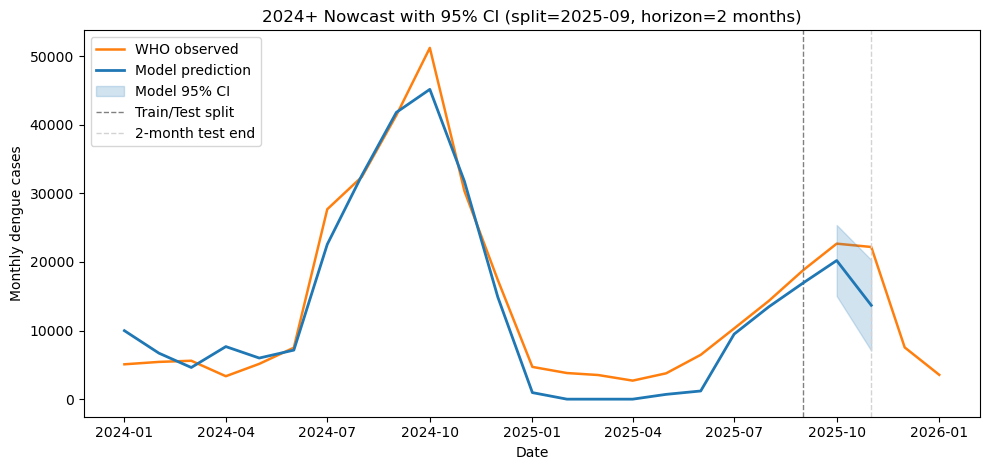

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2025-09.png


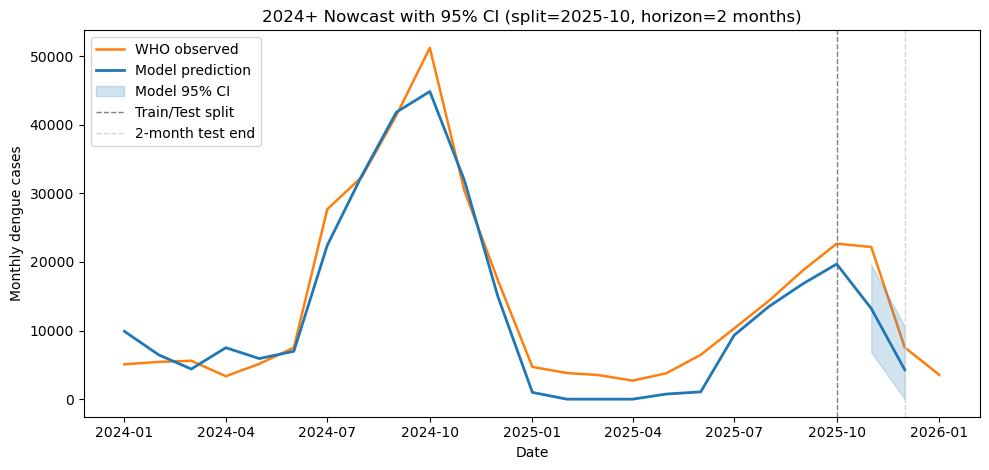

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2025-10.png


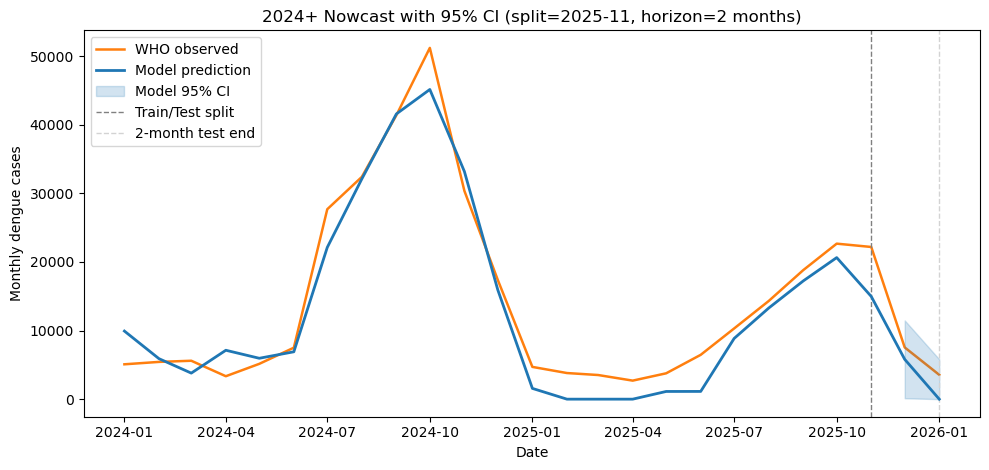

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2025-11.png


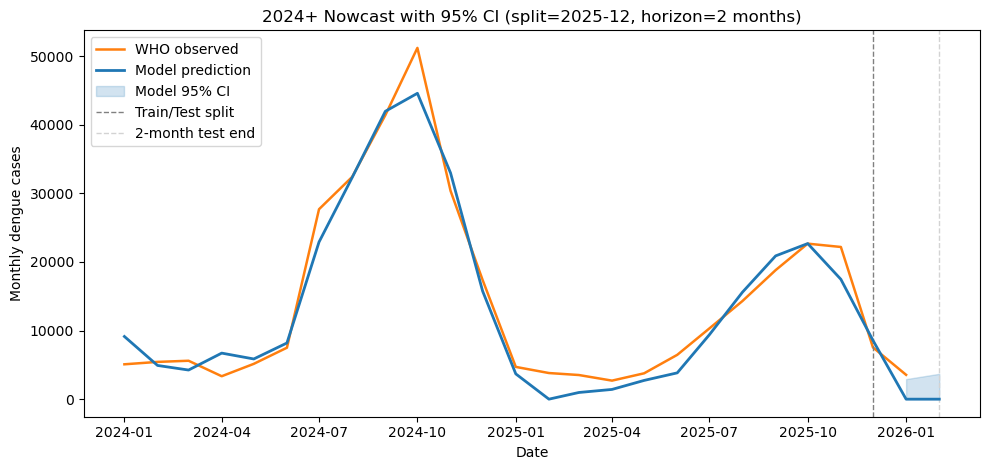

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/pred_ci_2month_test_window_split_2025-12.png
Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/rolling_prediction_intervals_2month_test_window_long.csv


In [8]:
# -------------------------
# Plot 2024+ WHO observations plus ONLY the 2-month test-window model predictions
# with 95% CI (one figure per rolling split)
# - show the model line only on the two post-split test months
# - show the CI band only on those same two months
# - do not shade the split/test region in the background
# -------------------------
from statistics import NormalDist
import re

if 'coef_long_df' not in globals() or len(coef_long_df) == 0:
    raise ValueError('coef_long_df is empty. Run the rolling split cell first.')

ci_rows = []

for split_month_ci in rolling_metrics_df['split_month'].tolist():
    train_mask, test_mask = time_series_split_mask(
        X_df.index,
        split_month_ci,
        horizon_months=int(cfg.test_horizon_months),
    )

    intercept_idx = feature_cols.index('intercept') if 'intercept' in feature_cols else None
    skip_cols = [intercept_idx] if intercept_idx is not None else []

    if cfg.standardize_features:
        X_proc, feat_mean, feat_std = standardize_features(X_raw, train_mask, skip_cols=skip_cols)
    else:
        X_proc = X_raw.copy()
        feat_mean = None
        feat_std = None

    year_constraints = build_year_constraints(X_df.index, yearly_proxy, train_mask)

    coef_sub = coef_long_df[coef_long_df['split_month'].eq(split_month_ci)].set_index('feature')
    beta_hat = np.array([float(coef_sub.loc[f, 'beta_hat']) for f in feature_cols], dtype=float)

    cfg_ci = copy.deepcopy(cfg)
    cfg_ci.split_month = split_month_ci
    x_pred = make_predictions(X_proc, beta_hat, cfg_ci)

    ci = compute_beta_ci_hessian(
        X=X_proc,
        y_who=y_who,
        mask_who=mask_who,
        year_constraints=year_constraints,
        train_mask=train_mask,
        cfg=cfg_ci,
        feature_cols=feature_cols,
        beta_hat=beta_hat,
        feat_mean=feat_mean,
        feat_std=feat_std,
        intercept_idx=intercept_idx,
        alpha=float(getattr(cfg_ci, 'beta_ci_alpha', 0.05)),
    )
    Var_beta = ci.get('Var_beta', None)
    z = float(ci.get('z', NormalDist().inv_cdf(0.975)))

    dates = pd.to_datetime(X_df.index)
    display_mask = dates >= pd.Timestamp('2024-01-01')
    test_idx = np.where(np.asarray(test_mask, dtype=bool))[0]
    if len(test_idx) == 0:
        print(f'Skipped CI plot for split {split_month_ci}: empty 2-month test window.')
        continue

    pred_se = np.full(len(dates), np.nan, dtype=float)
    pred_lo = np.full(len(dates), np.nan, dtype=float)
    pred_hi = np.full(len(dates), np.nan, dtype=float)

    if Var_beta is not None and np.isfinite(Var_beta).any():
        x_test = X_proc[test_idx, :]
        pred_se_scaled = np.sqrt(np.einsum('ij,jk,ik->i', x_test, Var_beta, x_test))
        pred_se[test_idx] = pred_se_scaled * float(cfg_ci.target_scale)
        pred_lo[test_idx] = x_pred[test_idx] - z * pred_se[test_idx]
        pred_hi[test_idx] = x_pred[test_idx] + z * pred_se[test_idx]
        if cfg_ci.clip_nonnegative:
            pred_lo[test_idx] = np.maximum(pred_lo[test_idx], 0.0)
            pred_hi[test_idx] = np.maximum(pred_hi[test_idx], 0.0)
    else:
        print(f'Warning for split {split_month_ci}: Var_beta not available, plotting test-window prediction without CI.')

    # Keep CI ONLY on the 2-month post-split test window,
    # but show the model prediction line from 2024-01 through the end of that test window.
    pred_lo_test_only = np.full(len(dates), np.nan, dtype=float)
    pred_hi_test_only = np.full(len(dates), np.nan, dtype=float)
    pred_lo_test_only[test_idx] = pred_lo[test_idx]
    pred_hi_test_only[test_idx] = pred_hi[test_idx]

    # Optional WHO CI if present in master_data as separate sources (e.g., WHO_lower/WHO_upper)
    who_lo = None
    who_hi = None
    cols = list(wide.columns)
    lo_cands = [c for c in cols if re.search(r'who.*(lower|lo|lci|lb)$', str(c), flags=re.I)]
    hi_cands = [c for c in cols if re.search(r'who.*(upper|hi|uci|ub)$', str(c), flags=re.I)]
    if len(lo_cands) > 0 and len(hi_cands) > 0:
        who_lo = wide[lo_cands[0]].reindex(dates).to_numpy(dtype=float)
        who_hi = wide[hi_cands[0]].reindex(dates).to_numpy(dtype=float)

    fig = plt.figure(figsize=(10, 4.8))

    # WHO observed line for context
    plt.plot(
        dates[display_mask],
        y_who[display_mask],
        linewidth=1.8,
        color='tab:orange',
        label='WHO observed',
        zorder=2,
    )

    # Optional WHO CI band
    if who_lo is not None and who_hi is not None:
        who_mask = dates >= pd.Timestamp('2024-01-01')
        plt.fill_between(
            dates[who_mask],
            who_lo[who_mask],
            who_hi[who_mask],
            alpha=0.12,
            label='WHO CI',
            zorder=1,
        )

    split_dt = pd.to_datetime(split_month_ci + '-01')
    test_end_dt = dates[test_mask].max() if np.asarray(test_mask).any() else None

    x_pred_plot_only = np.full(len(dates), np.nan, dtype=float)
    pred_line_mask = display_mask.copy()
    if test_end_dt is not None:
        pred_line_mask = pred_line_mask & (dates <= test_end_dt)
    x_pred_plot_only[pred_line_mask] = x_pred[pred_line_mask]

    # Model prediction line from 2024-01 up to the end of the 2-month test window
    plt.plot(
        dates[display_mask],
        x_pred_plot_only[display_mask],
        linewidth=2,
        color='tab:blue',
        label='Model prediction',
        zorder=3,
    )

    # Model CI band ONLY on the 2-month-ahead test window
    if np.isfinite(pred_lo_test_only[test_idx]).any() and np.isfinite(pred_hi_test_only[test_idx]).any():
        plt.fill_between(
            dates[display_mask],
            pred_lo_test_only[display_mask],
            pred_hi_test_only[display_mask],
            alpha=0.20,
            color='tab:blue',
            label='Model 95% CI',
            zorder=2,
        )

    if split_dt >= pd.Timestamp('2024-01-01'):
        plt.axvline(split_dt, linestyle='--', color='gray', linewidth=1.0, label='Train/Test split')
    if test_end_dt is not None and test_end_dt >= pd.Timestamp('2024-01-01'):
        plt.axvline(test_end_dt, linestyle='--', color='lightgray', linewidth=1.0, label='2-month test end')

    plt.xlabel('Date')
    plt.ylabel('Monthly dengue cases')
    plt.title(f'2024+ Nowcast with 95% CI (split={split_month_ci}, horizon=2 months)')
    plt.legend(loc='upper left' if split_month_ci == '2025-12' else 'best')
    plt.tight_layout()

    out_png = roll_dir / f'pred_ci_2month_test_window_split_{split_month_ci}.png'
    fig.savefig(out_png, dpi=200)
    plt.show()
    print('Saved:', out_png.resolve())

    ci_rows.append(pd.DataFrame({
        'split_month': split_month_ci,
        'date': dates.strftime('%Y-%m'),
        'is_display_window': display_mask.astype(int),
        'is_test_window': np.asarray(test_mask, dtype=int),
        'x_pred_test_window_only': np.where(np.asarray(test_mask, dtype=bool), x_pred, np.nan),
        'pred_se': pred_se,
        'pred_lo_95_test_window_only': pred_lo_test_only,
        'pred_hi_95_test_window_only': pred_hi_test_only,
    }))

if len(ci_rows) > 0:
    pred_ci_df = pd.concat(ci_rows, ignore_index=True)
    pred_ci_path = roll_dir / 'rolling_prediction_intervals_2month_test_window_long.csv'
    pred_ci_df.to_csv(pred_ci_path, index=False)
    print('Saved:', pred_ci_path.resolve())
else:
    print('No CI tables were saved.')



## 3) Plot and Save Outputs

Includes:
- Training loss curve
- WHO vs predictions (with train/test split line)
- Yearly aggregation vs OpenDengue
- Step1 vs Step2 comparison
- Parameter and prediction tables

Updated rolling evaluation uses only the next 2 months after each split as the test window, and prediction-interval plots are generated for every rolling split.


In [9]:
# Optional: keep the original single-split outputs if you still want them.
# Set cfg.split_month to one of the rolling months (or any month) and re-run the original pipeline.
#
# Example:
#   cfg.split_month = '2025-04'
#   train_mask, test_mask = time_series_split_mask(X_df.index, cfg.split_month)
#   ... (then follow the original cells 8-11 logic)


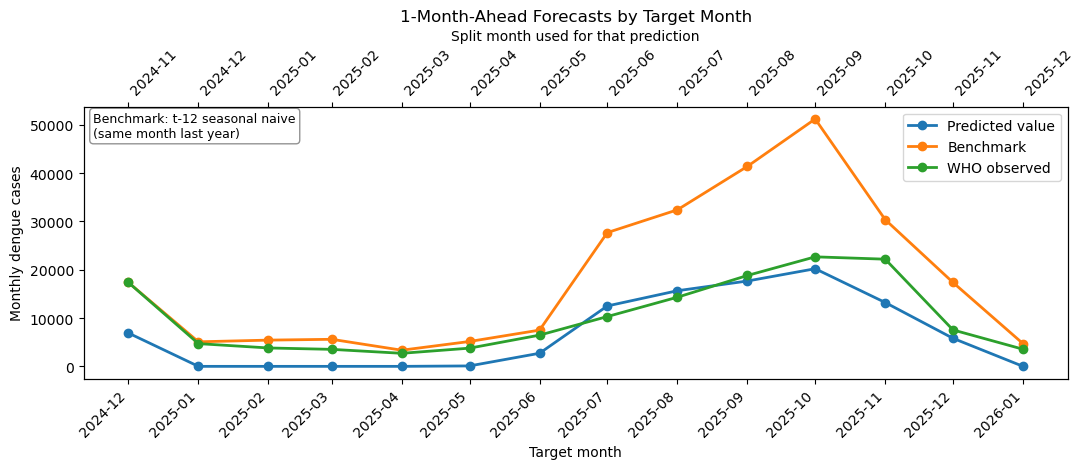

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/first_month_ahead_values.png


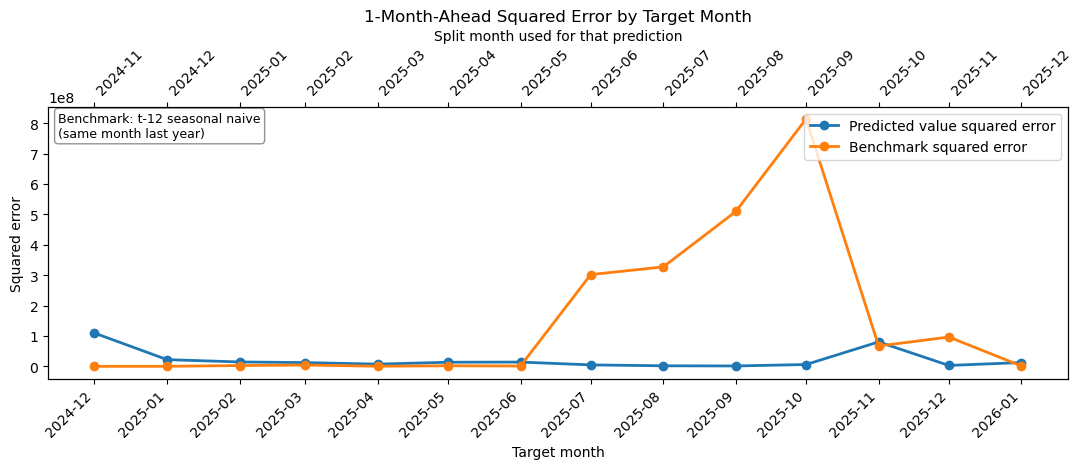

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/first_month_ahead_squared_error.png


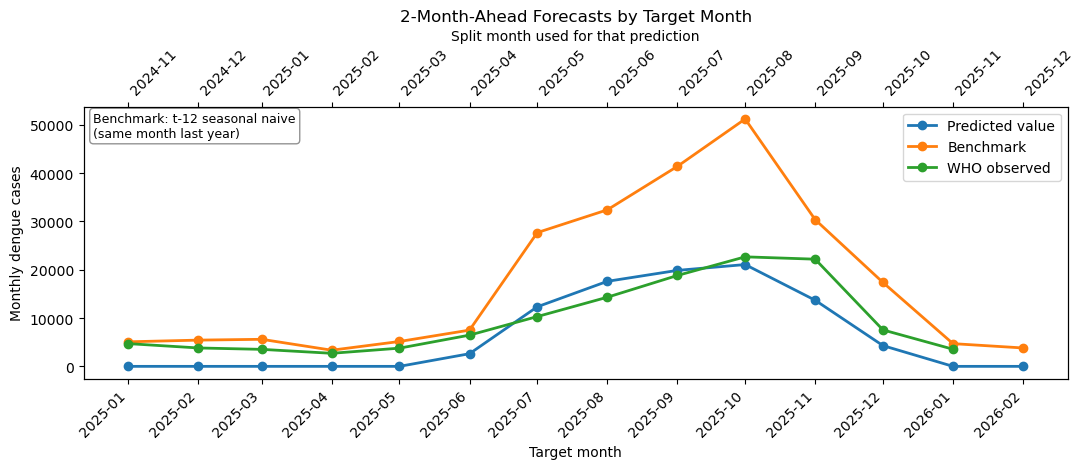

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/second_month_ahead_values.png


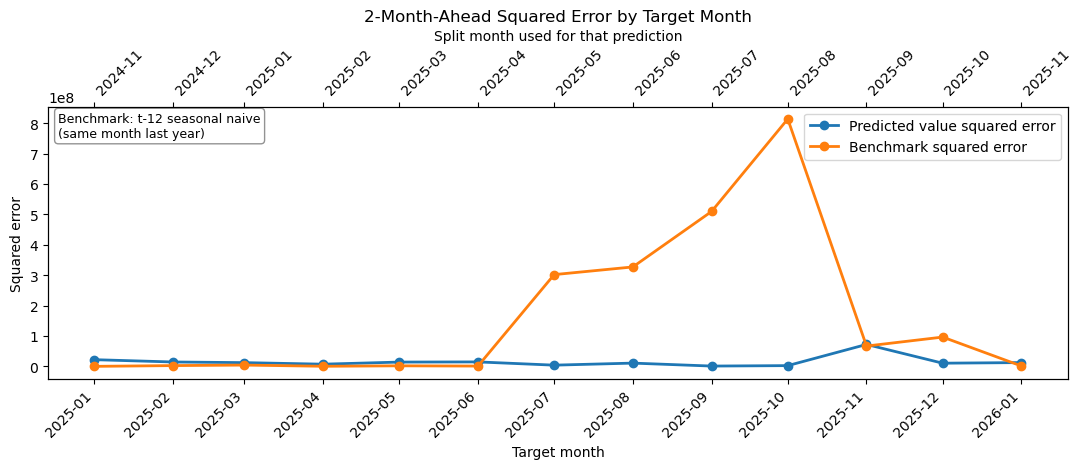

Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/second_month_ahead_squared_error.png
Saved: /Users/cathiesmac/Downloads/Nowcast Dengue in India/outputs_step2_mosquito/rolling_splits/horizon_specific_predictions_summary.csv


,split_month,split_date,target_month,target_date,horizon_step,x_pred,benchmark_t12,y_who,model_squared_error,benchmark_squared_error
0,2024-11,2024-11-01,2024-12,2024-12-01,1,6897.393307,17356.605469,17359.0,1.094452e+08,5.733780e+00
1,2024-12,2024-12-01,2025-01,2025-01-01,1,0.000000,5079.000000,4700.0,2.209000e+07,1.436410e+05
2,2025-01,2025-01-01,2025-02,2025-02-01,1,0.000000,5429.000000,3806.0,1.448564e+07,2.634129e+06
3,2025-02,2025-02-01,2025-03,2025-03-01,1,0.000000,5597.000000,3517.0,1.236929e+07,4.326400e+06
4,2025-03,2025-03-01,2025-04,2025-04-01,1,0.000000,3342.000000,2700.0,7.290000e+06,4.121640e+05


In [10]:
# -------------------------
# Horizon-specific results: first month ahead vs second month ahead
# Outputs: 4 figures
#   1) first-month-ahead values
#   2) first-month-ahead squared errors
#   3) second-month-ahead values
#   4) second-month-ahead squared errors
# -------------------------
if 'rolling_pred_df' not in globals() or len(rolling_pred_df) == 0:
    pred_path = roll_dir / 'rolling_predictions_long.csv'
    if pred_path.exists():
        rolling_pred_df = pd.read_csv(pred_path)
    else:
        raise ValueError('rolling_pred_df is empty. Run the rolling split cell first.')

plot_df = rolling_pred_df.copy()
plot_df['target_date'] = pd.to_datetime(plot_df['target_date'])
plot_df['split_date'] = pd.to_datetime(plot_df['split_date'])
plot_df = plot_df.sort_values(['horizon_step', 'target_date', 'split_date']).reset_index(drop=True)


def add_target_and_split_axes(ax, sub: pd.DataFrame) -> None:
    ticks = sub['target_date'].tolist()
    ax.set_xticks(ticks)
    ax.set_xticklabels(sub['target_month'].tolist(), rotation=45, ha='right')
    ax.set_xlabel('Target month')

    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(ticks)
    ax_top.set_xticklabels(sub['split_month'].tolist(), rotation=45, ha='left')
    ax_top.set_xlabel('Split month used for that prediction')


def add_benchmark_note(ax) -> None:
    ax.text(
        0.01, 0.98,
        'Benchmark: t-12 seasonal naive\n(same month last year)',
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray'),
    )


def plot_horizon_values(sub: pd.DataFrame, horizon_step: int, out_png: Path) -> None:
    fig = plt.figure(figsize=(11, 4.8))
    plt.plot(
        sub['target_date'], sub['x_pred'],
        marker='o', linewidth=2, color='tab:blue',
        label='Predicted value',
        zorder=1
    )
    plt.plot(
        sub['target_date'], sub['benchmark_t12'],
        marker='o', linewidth=2, color='tab:orange',
        label='Benchmark',
        zorder=2
    )
    plt.plot(
        sub['target_date'], sub['y_who'],
        marker='o', linewidth=2, color='tab:green',
        label='WHO observed',
        zorder=3
    )
    plt.ylabel('Monthly dengue cases')
    plt.title(f'{horizon_step}-Month-Ahead Forecasts by Target Month')
    ax = plt.gca()
    add_target_and_split_axes(ax, sub)
    add_benchmark_note(ax)
    ax.legend(loc='upper right')
    plt.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.show()
    print('Saved:', out_png.resolve())


def plot_horizon_errors(sub: pd.DataFrame, horizon_step: int, out_png: Path) -> None:
    err = sub.copy()
    err = err[np.isfinite(err['model_squared_error']) | np.isfinite(err['benchmark_squared_error'])].copy()
    fig = plt.figure(figsize=(11, 4.8))
    plt.plot(
        err['target_date'], err['model_squared_error'],
        marker='o', linewidth=2, color='tab:blue',
        label='Predicted value squared error',
        zorder=1
    )
    plt.plot(
        err['target_date'], err['benchmark_squared_error'],
        marker='o', linewidth=2, color='tab:orange',
        label='Benchmark squared error',
        zorder=2
    )
    plt.ylabel('Squared error')
    plt.title(f'{horizon_step}-Month-Ahead Squared Error by Target Month')
    ax = plt.gca()
    add_target_and_split_axes(ax, err)
    add_benchmark_note(ax)
    ax.legend(loc='upper right')
    plt.tight_layout()
    fig.savefig(out_png, dpi=200)
    plt.show()
    print('Saved:', out_png.resolve())


for horizon_step, tag in [(1, 'first'), (2, 'second')]:
    sub = plot_df[plot_df['horizon_step'].eq(horizon_step)].copy()
    if sub.empty:
        print(f'No rows found for horizon_step={horizon_step}.')
        continue

    value_png = roll_dir / f'{tag}_month_ahead_values.png'
    error_png = roll_dir / f'{tag}_month_ahead_squared_error.png'
    plot_horizon_values(sub, horizon_step, value_png)
    plot_horizon_errors(sub, horizon_step, error_png)

summary_cols = [
    'split_month', 'target_month', 'horizon_step',
    'x_pred', 'benchmark_t12', 'y_who',
    'model_squared_error', 'benchmark_squared_error'
]
summary_path = roll_dir / 'horizon_specific_predictions_summary.csv'
plot_df.loc[:, summary_cols].to_csv(summary_path, index=False)
print('Saved:', summary_path.resolve())

plot_df.head()
